# Project 4: Healthcare Analytics — COVID Patient Analysis
**Internship Data Analytics — Project 4**

| Item | Detail |
|------|--------|
| Dataset | covid_patient_data.csv |
| Records | 15,000 patient admissions |
| Period | Jan 2020 – Dec 2022 |
| States | 10 Indian states |
| Tools | Python, Pandas, Matplotlib, NumPy, SciPy |

---
## CELL 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 25)
plt.rcParams.update({
    'font.family':'DejaVu Sans','font.size':11,
    'axes.spines.top':False,'axes.spines.right':False,
    'axes.grid':True,'grid.alpha':0.3,'grid.linestyle':'--',
    'figure.facecolor':'#FAFAFA','axes.facecolor':'#FAFAFA',
})
SEV_COLORS = {'Mild':'#27AE60','Moderate':'#F39C12','Severe':'#E74C3C','Critical':'#7D3C98'}
OUT_COLORS = {'Recovered':'#1E8449','Deceased':'#C0392B'}
VAX_COLORS = {'Covishield':'#1B4F72','Covaxin':'#27AE60','Sputnik V':'#8E44AD','Not Vaccinated':'#C0392B'}
print('Libraries loaded')

Libraries loaded


---
## CELL 2 — Load Dataset

In [2]:
df = pd.read_csv('covid_patient_data.csv', parse_dates=['admission_date'])
mort_rate = (df['outcome']=='Deceased').mean()*100
print(f'Shape         : {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Period        : {df["admission_date"].min().date()} to {df["admission_date"].max().date()}')
print(f'Mortality Rate: {mort_rate:.2f}%')
print(f'Avg Stay      : {df["hospital_stay_days"].mean():.1f} days')
print(f'Vaccinated    : {(df["vaccine_status"]!="Not Vaccinated").mean()*100:.1f}%')
df.head()

Shape         : 15,000 rows x 20 columns
Period        : 2020-01-01 to 2022-12-31
Mortality Rate: 8.74%
Avg Stay      : 11.3 days
Vaccinated    : 65.2%


,patient_id,admission_date,year,month,state,age,age_group,gender,blood_group,vaccine_status,comorbidity,severity,treatment,hospital_stay_days,outcome,spo2_admission,temperature_f,systolic_bp,heart_rate,treatment_effectiveness_pct
0,P00001,2020-06-27,2020,6,Uttar Pradesh,53,46-60,Male,O+,Covishield,NaN,Moderate,Remdesivir,7,Recovered,96,102.3,140,90,74.8
1,P00002,2020-11-22,2020,11,Maharashtra,73,61-75,Male,AB+,Covishield,Hypertension,Severe,Remdesivir,16,Deceased,95,100.9,138,86,61.7
2,P00003,2022-07-29,2022,7,Maharashtra,49,46-60,Male,O-,Not Vaccinated,Hypertension,Moderate,Remdesivir,8,Recovered,91,99.4,121,76,77.6
3,P00004,2021-08-15,2021,8,Gujarat,28,18-30,Male,B-,Not Vaccinated,NaN,Critical,Dexamethasone,23,Recovered,88,103.3,114,96,20.9
4,P00005,2020-05-26,2020,5,Karnataka,35,31-45,Male,B-,Not Vaccinated,Hypertension,Moderate,Supportive Care,10,Recovered,97,100.1,135,84,71.5


---
## CELL 3 — Data Quality

In [3]:
print('=== MISSING VALUES ===')
miss = df.isnull().sum()
print(miss[miss>0] if miss.any() else 'No missing values')

print('\n=== NUMERIC STATS ===')
print(df[['age','hospital_stay_days','spo2_admission','temperature_f',
           'systolic_bp','heart_rate','treatment_effectiveness_pct']].describe().round(2).to_string())

print('\n=== VALIDATIONS ===')
checks = {
    'Age in [1,95]'           : df['age'].between(1,95).all(),
    'SpO2 in [70,100]'        : df['spo2_admission'].between(70,100).all(),
    'Stay days > 0'           : (df['hospital_stay_days']>0).all(),
    'Outcome is valid'        : df['outcome'].isin(['Recovered','Deceased']).all(),
    'Severity is valid'       : df['severity'].isin(['Mild','Moderate','Severe','Critical']).all(),
    'Treatment eff in [0,100]': df['treatment_effectiveness_pct'].between(0,100).all(),
    'No duplicate patient IDs': df['patient_id'].nunique()==len(df),
    'BP > 0'                  : (df['systolic_bp']>0).all(),
}
for k,v in checks.items():
    print(f'  {"PASS" if v else "FAIL"}  {k}')

=== MISSING VALUES ===
comorbidity    5981
dtype: int64

=== NUMERIC STATS ===
            age  hospital_stay_days  spo2_admission  temperature_f  systolic_bp  heart_rate  treatment_effectiveness_pct
count  15000.00            15000.00        15000.00       15000.00     15000.00    15000.00                     15000.00
mean      44.55               11.30           95.25         100.74       119.31       94.62                        75.65
std       18.01                7.11            3.29           1.54        15.54       17.90                        16.44
min        1.00                3.00           83.00          97.00        80.00       55.00                        20.00
25%       32.00                6.00           93.00          99.70       109.00       82.00                        66.60
50%       45.00                9.00           96.00         100.80       119.00       94.00                        79.10
75%       57.00               15.00           98.00         101.90       1

---
## CELL 4 — Key Healthcare KPIs

In [4]:
print('=== SEVERITY BREAKDOWN ===')
sev_stats = df.groupby('severity').agg(
    patients     =('patient_id','count'),
    mortality_pct=('outcome', lambda x:(x=='Deceased').mean()*100),
    avg_stay     =('hospital_stay_days','mean'),
    avg_spo2     =('spo2_admission','mean'),
).round(2)
print(sev_stats.to_string())

print('\n=== VACCINE EFFECTIVENESS ===')
vax_stats = df.groupby('vaccine_status').agg(
    patients     =('patient_id','count'),
    mortality_pct=('outcome', lambda x:(x=='Deceased').mean()*100),
    severe_pct   =('severity', lambda x:(x.isin(['Severe','Critical'])).mean()*100),
    avg_stay     =('hospital_stay_days','mean'),
).round(2)
print(vax_stats.to_string())

print('\n=== TREATMENT COMPARISON ===')
treat_stats = df.groupby('treatment').agg(
    patients =('patient_id','count'),
    mortality=('outcome', lambda x:(x=='Deceased').mean()*100),
    avg_eff  =('treatment_effectiveness_pct','mean'),
    avg_stay =('hospital_stay_days','mean'),
).round(2).sort_values('avg_eff', ascending=False)
print(treat_stats.to_string())

=== SEVERITY BREAKDOWN ===
          patients  mortality_pct  avg_stay  avg_spo2
severity                                             
Critical      1048          57.92     24.90     92.40
Mild          5802           0.38      5.00     96.36
Moderate      4962           2.72     10.55     96.36
Severe        3188          17.16     19.48     92.44

=== VACCINE EFFECTIVENESS ===
                patients  mortality_pct  severe_pct  avg_stay
vaccine_status                                               
Covaxin             3774           5.59       24.06     10.62
Covishield          5245           5.87       24.75     10.76
Not Vaccinated      5219          14.41       35.52     12.45
Sputnik V            762           5.25       23.10     10.56

=== TREATMENT COMPARISON ===
                    patients  mortality  avg_eff  avg_stay
treatment                                                 
Oxygen Therapy          2532       8.77    76.06     11.28
Hydroxychloroquine      2469       7.82

---
## CELL 5 — VIZ 1: Patient Overview Dashboard

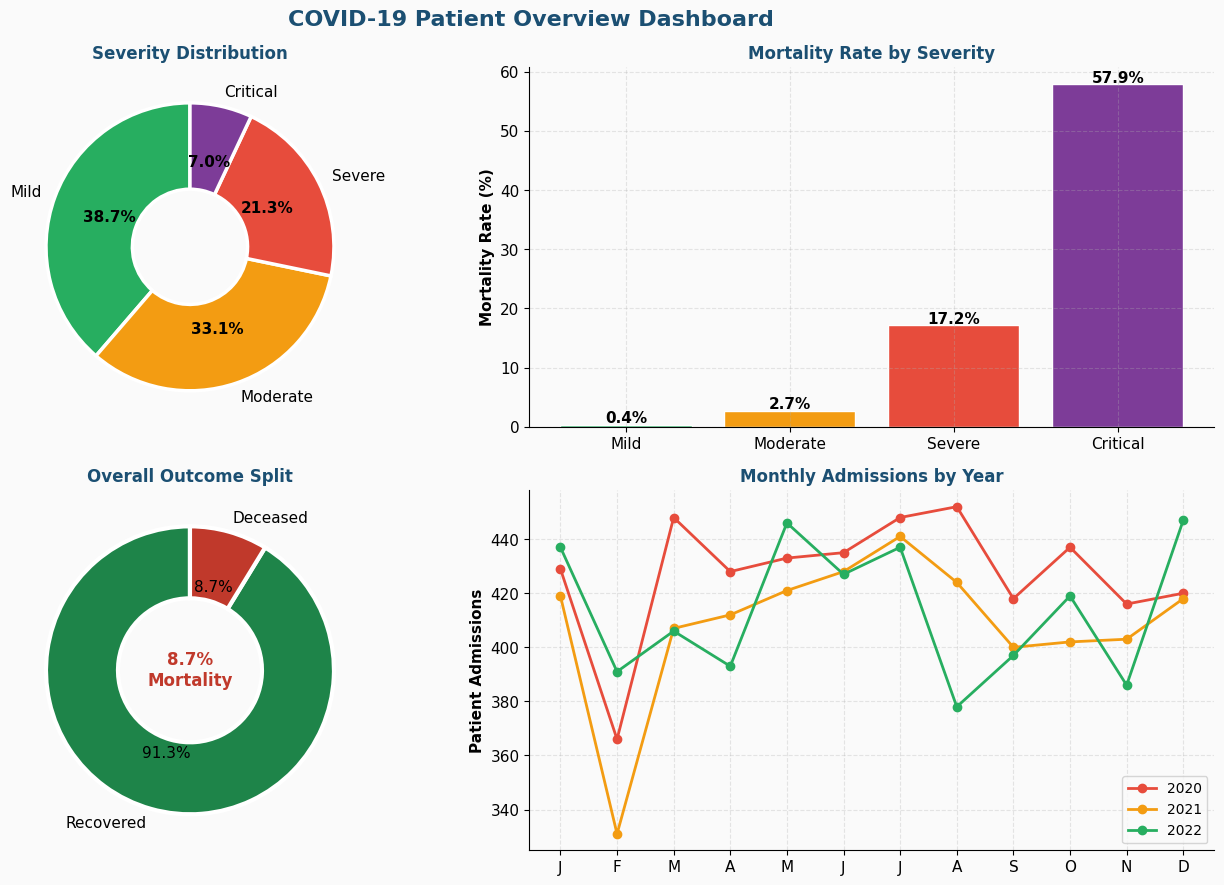

In [5]:
sev_order  = ['Mild','Moderate','Severe','Critical']
sev_counts = df['severity'].value_counts().reindex(sev_order)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.patch.set_facecolor('#FAFAFA')
fig.suptitle('COVID-19 Patient Overview Dashboard', fontsize=16, fontweight='bold', color='#1B4F72')

wedges,texts,autotexts = axes[0,0].pie(
    sev_counts.values, labels=sev_order, autopct='%1.1f%%',
    colors=[SEV_COLORS[s] for s in sev_order], startangle=90,
    wedgeprops={'edgecolor':'white','linewidth':2.5,'width':0.6})
for at in autotexts: at.set_fontweight('bold')
axes[0,0].set_title('Severity Distribution', fontsize=12, fontweight='bold', color='#1B4F72')

sev_mort = df.groupby('severity')['outcome'].apply(
    lambda x:(x=='Deceased').mean()*100).reindex(sev_order)
bars = axes[0,1].bar(sev_order, sev_mort.values,
                     color=[SEV_COLORS[s] for s in sev_order], edgecolor='white')
for bar,val in zip(bars,sev_mort.values):
    axes[0,1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                   f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
axes[0,1].set_ylabel('Mortality Rate (%)', fontweight='bold')
axes[0,1].set_title('Mortality Rate by Severity', fontsize=12, fontweight='bold', color='#1B4F72')

out_counts = df['outcome'].value_counts()
axes[1,0].pie(out_counts.values, labels=out_counts.index, autopct='%1.1f%%',
              colors=[OUT_COLORS[k] for k in out_counts.index], startangle=90,
              wedgeprops={'edgecolor':'white','linewidth':3,'width':0.5})
axes[1,0].text(0,0,f'{mort_rate:.1f}%\nMortality',ha='center',va='center',
               fontsize=12,fontweight='bold',color='#C0392B')
axes[1,0].set_title('Overall Outcome Split', fontsize=12, fontweight='bold', color='#1B4F72')

monthly_admits = df.groupby(['year','month']).size().reset_index(name='count')
for yr, color in [(2020,'#E74C3C'),(2021,'#F39C12'),(2022,'#27AE60')]:
    sub = monthly_admits[monthly_admits['year']==yr]
    axes[1,1].plot(sub['month'], sub['count'], 'o-',
                   color=color, linewidth=2, markersize=6, label=str(yr))
axes[1,1].set_xticks(range(1,13))
axes[1,1].set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
axes[1,1].set_ylabel('Patient Admissions', fontweight='bold')
axes[1,1].set_title('Monthly Admissions by Year', fontsize=12, fontweight='bold', color='#1B4F72')
axes[1,1].legend(fontsize=10)

plt.tight_layout()
plt.show()

---
## CELL 6 — VIZ 2: Age & Gender Analysis

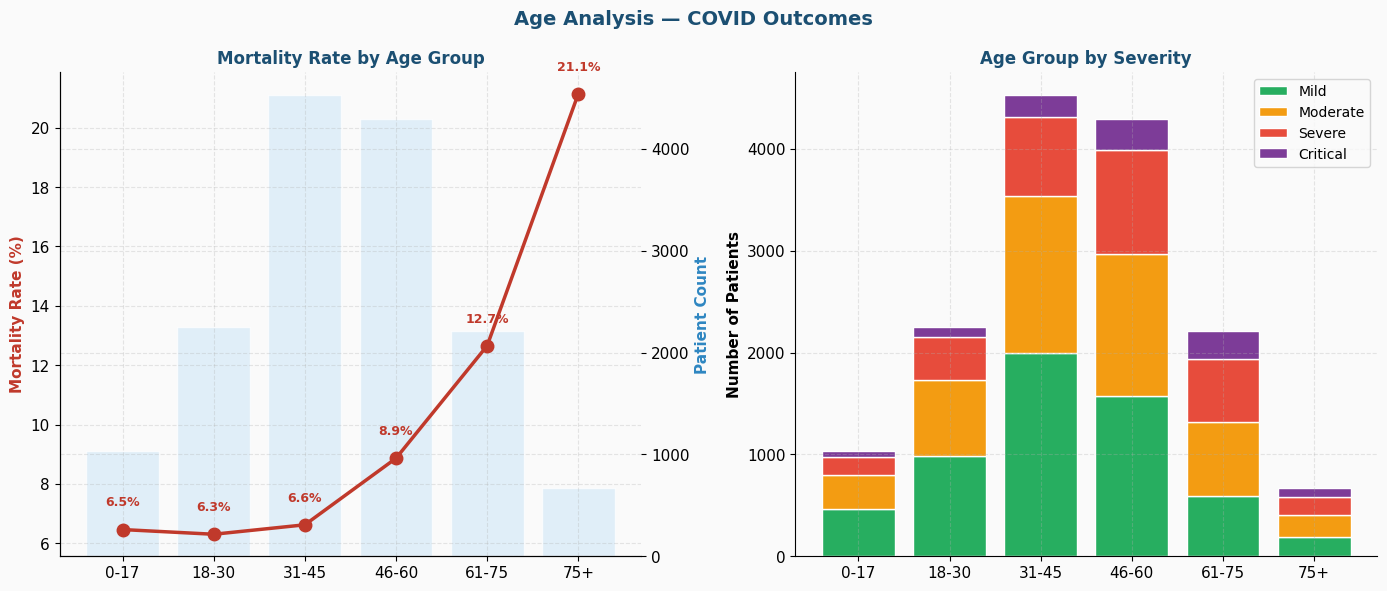

In [6]:
age_order = ['0-17','18-30','31-45','46-60','61-75','75+']
age_mort  = df.groupby('age_group')['outcome'].apply(
    lambda x:(x=='Deceased').mean()*100).reindex(age_order)
age_count = df.groupby('age_group')['patient_id'].count().reindex(age_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#FAFAFA')
fig.suptitle('Age Analysis — COVID Outcomes', fontsize=14, fontweight='bold', color='#1B4F72')

x   = np.arange(len(age_order))
ax2 = axes[0].twinx()
ax2.bar(x, age_count.values, color='#D6EAF8', edgecolor='white', alpha=0.7, zorder=1)
axes[0].plot(x, age_mort.values, 'o-', color='#C0392B', linewidth=2.5, markersize=9, zorder=2)
for xv,yv in zip(x, age_mort.values):
    axes[0].text(xv, yv+0.8, f'{yv:.1f}%', ha='center', fontsize=9,
                 fontweight='bold', color='#C0392B', zorder=3)
axes[0].set_xticks(x)
axes[0].set_xticklabels(age_order)
axes[0].set_ylabel('Mortality Rate (%)', color='#C0392B', fontweight='bold')
ax2.set_ylabel('Patient Count', color='#2E86C1', fontweight='bold')
axes[0].set_title('Mortality Rate by Age Group', fontsize=12, fontweight='bold', color='#1B4F72')
ax2.spines['top'].set_visible(False)
axes[0].set_zorder(ax2.get_zorder()+1)
axes[0].patch.set_visible(False)

age_sev = df.groupby(['age_group','severity']).size().reset_index(name='count')
age_sev_piv = age_sev.pivot(index='age_group',columns='severity',
                             values='count').fillna(0).reindex(age_order)
bottom = np.zeros(len(age_order))
for sev in ['Mild','Moderate','Severe','Critical']:
    if sev in age_sev_piv.columns:
        axes[1].bar(age_order, age_sev_piv[sev].values, bottom=bottom,
                    label=sev, color=SEV_COLORS[sev], edgecolor='white')
        bottom += age_sev_piv[sev].values
axes[1].set_ylabel('Number of Patients', fontweight='bold')
axes[1].set_title('Age Group by Severity', fontsize=12, fontweight='bold', color='#1B4F72')
axes[1].legend(fontsize=10)
plt.tight_layout()
plt.show()

---
## CELL 7 — VIZ 3: Vaccine Effectiveness

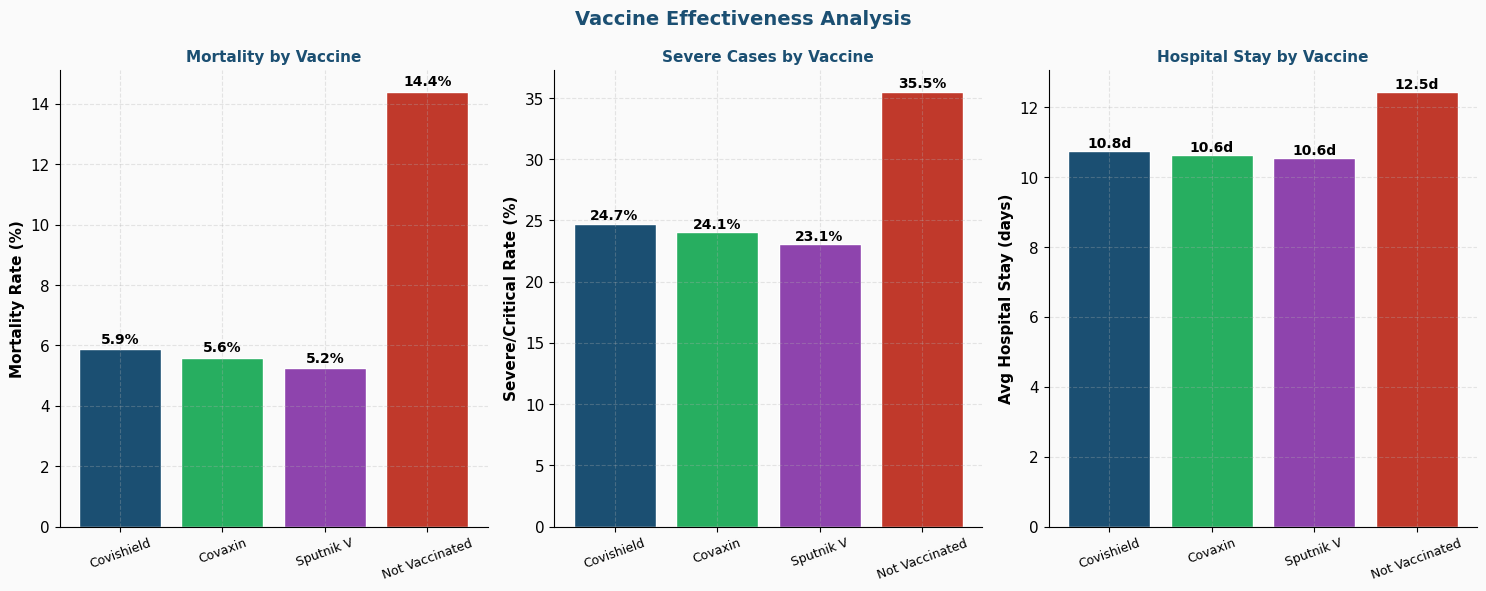

In [7]:
vax_order = ['Covishield','Covaxin','Sputnik V','Not Vaccinated']
colors_v  = [VAX_COLORS[v] for v in vax_order]

fig, axes = plt.subplots(1, 3, figsize=(15, 6))
fig.patch.set_facecolor('#FAFAFA')
fig.suptitle('Vaccine Effectiveness Analysis', fontsize=14, fontweight='bold', color='#1B4F72')

vax_mort = df.groupby('vaccine_status')['outcome'].apply(
    lambda x:(x=='Deceased').mean()*100).reindex(vax_order)
bars = axes[0].bar(vax_order, vax_mort.values, color=colors_v, edgecolor='white')
for bar,val in zip(bars,vax_mort.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                 f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
axes[0].set_ylabel('Mortality Rate (%)', fontweight='bold')
axes[0].set_title('Mortality by Vaccine', fontsize=11, fontweight='bold', color='#1B4F72')
axes[0].tick_params(axis='x', rotation=20, labelsize=9)

vax_sev = df.groupby('vaccine_status')['severity'].apply(
    lambda x: x.isin(['Severe','Critical']).mean()*100).reindex(vax_order)
bars2 = axes[1].bar(vax_order, vax_sev.values, color=colors_v, edgecolor='white')
for bar,val in zip(bars2,vax_sev.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
axes[1].set_ylabel('Severe/Critical Rate (%)', fontweight='bold')
axes[1].set_title('Severe Cases by Vaccine', fontsize=11, fontweight='bold', color='#1B4F72')
axes[1].tick_params(axis='x', rotation=20, labelsize=9)

vax_stay = df.groupby('vaccine_status')['hospital_stay_days'].mean().reindex(vax_order)
bars3 = axes[2].bar(vax_order, vax_stay.values, color=colors_v, edgecolor='white')
for bar,val in zip(bars3,vax_stay.values):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                 f'{val:.1f}d', ha='center', fontsize=10, fontweight='bold')
axes[2].set_ylabel('Avg Hospital Stay (days)', fontweight='bold')
axes[2].set_title('Hospital Stay by Vaccine', fontsize=11, fontweight='bold', color='#1B4F72')
axes[2].tick_params(axis='x', rotation=20, labelsize=9)

plt.tight_layout()
plt.show()

---
## CELL 8 — VIZ 4: Comorbidity Impact

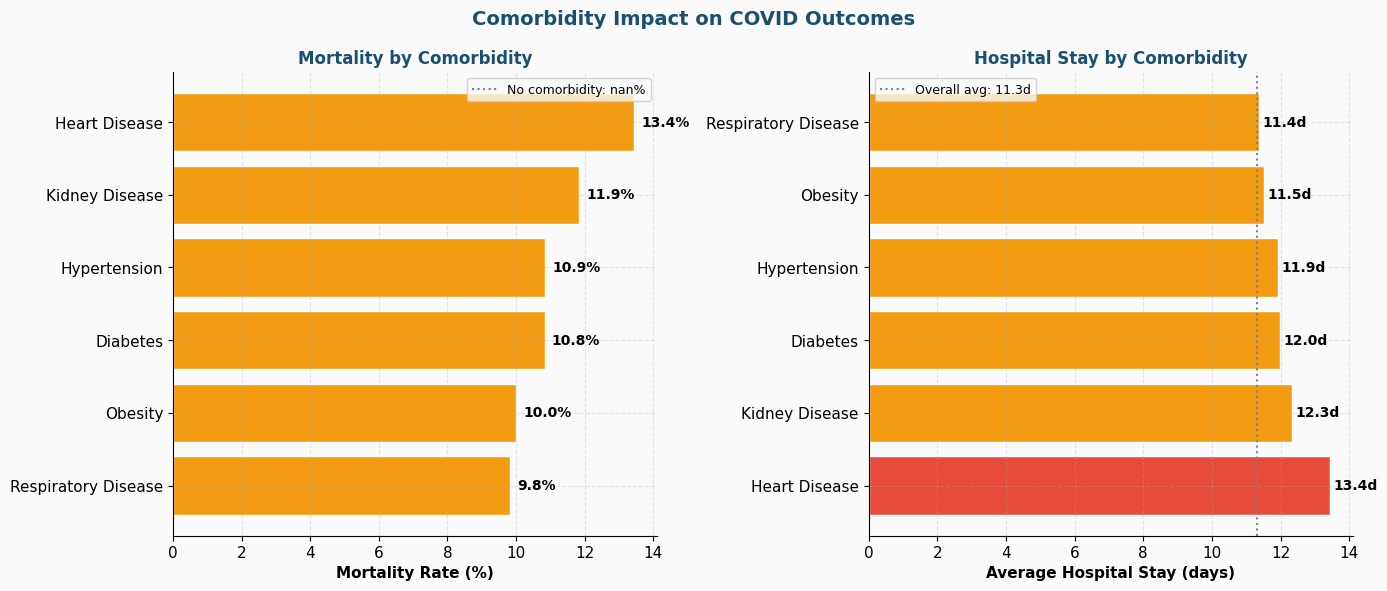

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#FAFAFA')
fig.suptitle('Comorbidity Impact on COVID Outcomes', fontsize=14, fontweight='bold', color='#1B4F72')

comorbid_mort = df.groupby('comorbidity')['outcome'].apply(
    lambda x:(x=='Deceased').mean()*100).sort_values(ascending=True)
bc = ['#27AE60' if v<8 else '#F39C12' if v<15 else '#E74C3C' for v in comorbid_mort.values]
bars = axes[0].barh(comorbid_mort.index, comorbid_mort.values, color=bc, edgecolor='white')
for bar,val in zip(bars,comorbid_mort.values):
    axes[0].text(bar.get_width()+0.2, bar.get_y()+bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')
baseline = df[df['comorbidity']=='None']['outcome'].apply(lambda x:x=='Deceased').mean()*100
axes[0].axvline(baseline, color='gray', linestyle=':', linewidth=1.5,
                label=f'No comorbidity: {baseline:.1f}%')
axes[0].set_xlabel('Mortality Rate (%)', fontweight='bold')
axes[0].set_title('Mortality by Comorbidity', fontsize=12, fontweight='bold', color='#1B4F72')
axes[0].legend(fontsize=9)

comorbid_stay = df.groupby('comorbidity')['hospital_stay_days'].mean().sort_values(ascending=False)
cs = ['#E74C3C' if v>13 else '#F39C12' if v>10 else '#27AE60' for v in comorbid_stay.values]
bars2 = axes[1].barh(comorbid_stay.index, comorbid_stay.values, color=cs, edgecolor='white')
for bar,val in zip(bars2,comorbid_stay.values):
    axes[1].text(bar.get_width()+0.1, bar.get_y()+bar.get_height()/2,
                 f'{val:.1f}d', va='center', fontsize=10, fontweight='bold')
axes[1].axvline(df['hospital_stay_days'].mean(), color='gray', linestyle=':', linewidth=1.5,
                label=f'Overall avg: {df["hospital_stay_days"].mean():.1f}d')
axes[1].set_xlabel('Average Hospital Stay (days)', fontweight='bold')
axes[1].set_title('Hospital Stay by Comorbidity', fontsize=12, fontweight='bold', color='#1B4F72')
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.show()

---
## CELL 9 — VIZ 5: Treatment Effectiveness

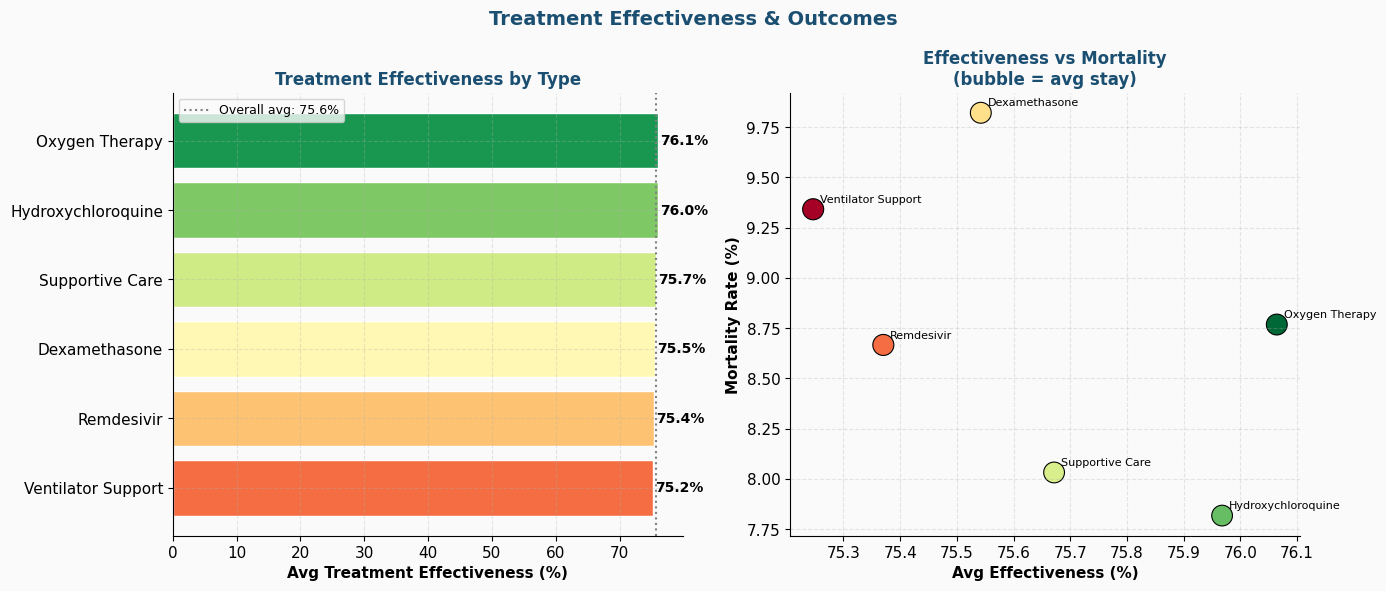

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#FAFAFA')
fig.suptitle('Treatment Effectiveness & Outcomes', fontsize=14, fontweight='bold', color='#1B4F72')

treat_eff = df.groupby('treatment').agg(
    avg_eff  =('treatment_effectiveness_pct','mean'),
    mortality=('outcome', lambda x:(x=='Deceased').mean()*100),
    avg_stay =('hospital_stay_days','mean')
).sort_values('avg_eff', ascending=True)

tc = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(treat_eff)))
bars = axes[0].barh(treat_eff.index, treat_eff['avg_eff'].values, color=tc, edgecolor='white')
for bar,val in zip(bars,treat_eff['avg_eff'].values):
    axes[0].text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')
avg_eff_all = df['treatment_effectiveness_pct'].mean()
axes[0].axvline(avg_eff_all, color='gray', linestyle=':', linewidth=1.5,
                label=f'Overall avg: {avg_eff_all:.1f}%')
axes[0].set_xlabel('Avg Treatment Effectiveness (%)', fontweight='bold')
axes[0].set_title('Treatment Effectiveness by Type', fontsize=12, fontweight='bold', color='#1B4F72')
axes[0].legend(fontsize=9)

axes[1].scatter(treat_eff['avg_eff'], treat_eff['mortality'],
                s=treat_eff['avg_stay']*20, c=range(len(treat_eff)),
                cmap='RdYlGn', edgecolors='black', linewidth=0.8)
for t, row in treat_eff.iterrows():
    axes[1].annotate(t, (row['avg_eff'], row['mortality']),
                     textcoords='offset points', xytext=(5,5), fontsize=8)
axes[1].set_xlabel('Avg Effectiveness (%)', fontweight='bold')
axes[1].set_ylabel('Mortality Rate (%)', fontweight='bold')
axes[1].set_title('Effectiveness vs Mortality\n(bubble = avg stay)', fontsize=12,
                   fontweight='bold', color='#1B4F72')
plt.tight_layout()
plt.show()

---
## CELL 10 — VIZ 6: Patient Vitals

=== T-TESTS: RECOVERED vs DECEASED ===
  spo2_admission              : Recovered=95.48  Deceased=92.89  p=0.000000
  temperature_f               : Recovered=100.67  Deceased=101.50  p=0.000000
  systolic_bp                 : Recovered=119.23  Deceased=120.13  p=0.044981
  heart_rate                  : Recovered=94.65  Deceased=94.26  p=0.451705


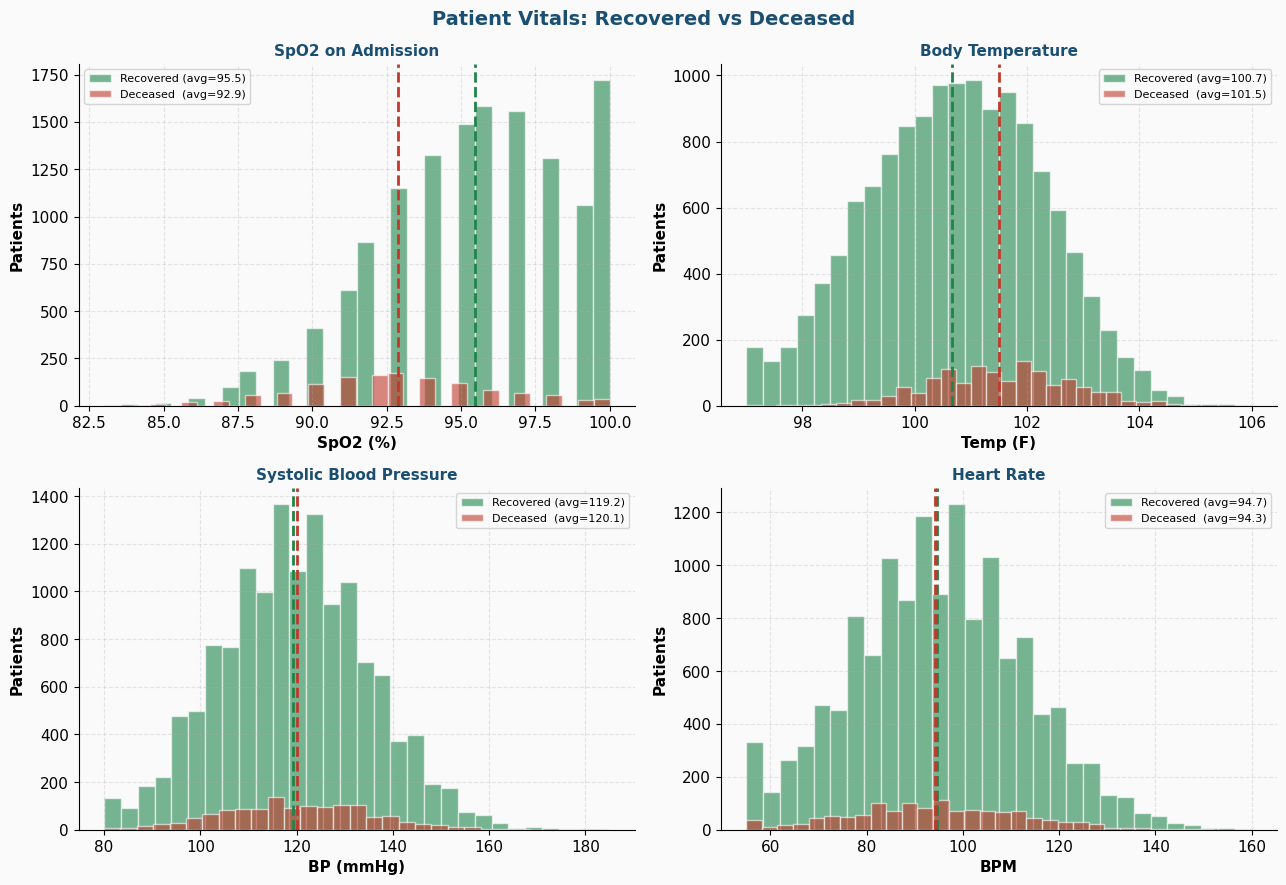

In [10]:
print('=== T-TESTS: RECOVERED vs DECEASED ===')
for col in ['spo2_admission','temperature_f','systolic_bp','heart_rate']:
    rec = df[df['outcome']=='Recovered'][col]
    dec = df[df['outcome']=='Deceased'][col]
    t,p = stats.ttest_ind(rec, dec)
    print(f'  {col:28s}: Recovered={rec.mean():.2f}  Deceased={dec.mean():.2f}  p={p:.6f}')

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.patch.set_facecolor('#FAFAFA')
fig.suptitle('Patient Vitals: Recovered vs Deceased', fontsize=14, fontweight='bold', color='#1B4F72')

vitals = [
    ('spo2_admission','SpO2 on Admission','SpO2 (%)'),
    ('temperature_f','Body Temperature','Temp (F)'),
    ('systolic_bp','Systolic Blood Pressure','BP (mmHg)'),
    ('heart_rate','Heart Rate','BPM'),
]
for ax, (col, title, xlabel) in zip(axes.flat, vitals):
    rec = df[df['outcome']=='Recovered'][col]
    dec = df[df['outcome']=='Deceased'][col]
    ax.hist(rec, bins=30, alpha=0.6, color='#1E8449',
            label=f'Recovered (avg={rec.mean():.1f})', edgecolor='white')
    ax.hist(dec, bins=30, alpha=0.6, color='#C0392B',
            label=f'Deceased  (avg={dec.mean():.1f})', edgecolor='white')
    ax.axvline(rec.mean(), color='#1E8449', linestyle='--', linewidth=2)
    ax.axvline(dec.mean(), color='#C0392B', linestyle='--', linewidth=2)
    ax.set_xlabel(xlabel, fontweight='bold')
    ax.set_ylabel('Patients', fontweight='bold')
    ax.set_title(title, fontsize=11, fontweight='bold', color='#1B4F72')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

---
## CELL 11 — VIZ 7: State-wise Analysis

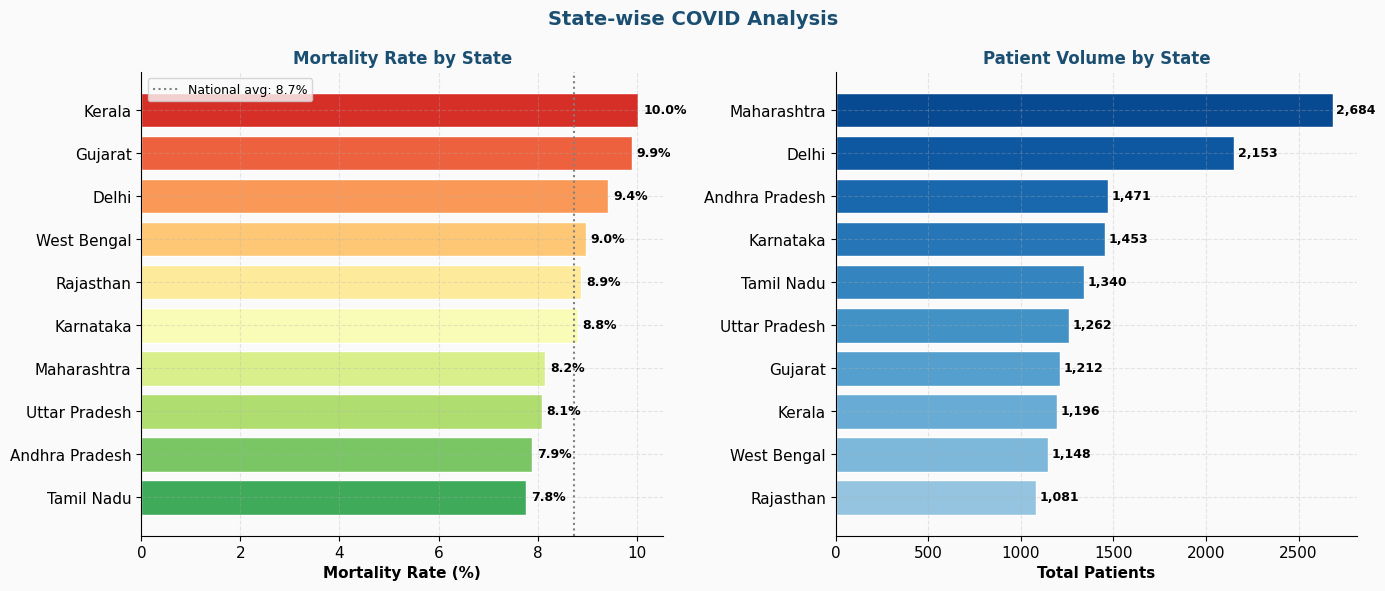

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#FAFAFA')
fig.suptitle('State-wise COVID Analysis', fontsize=14, fontweight='bold', color='#1B4F72')

state_stats = df.groupby('state').agg(
    patients =('patient_id','count'),
    mortality=('outcome', lambda x:(x=='Deceased').mean()*100),
).sort_values('mortality', ascending=True)

sc = plt.cm.RdYlGn(np.linspace(0.85, 0.1, len(state_stats)))
bars = axes[0].barh(state_stats.index, state_stats['mortality'], color=sc, edgecolor='white')
for bar,val in zip(bars, state_stats['mortality']):
    axes[0].text(bar.get_width()+0.1, bar.get_y()+bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')
axes[0].axvline(mort_rate, color='gray', linestyle=':',
                linewidth=1.5, label=f'National avg: {mort_rate:.1f}%')
axes[0].set_xlabel('Mortality Rate (%)', fontweight='bold')
axes[0].set_title('Mortality Rate by State', fontsize=12, fontweight='bold', color='#1B4F72')
axes[0].legend(fontsize=9)

state_vol = df['state'].value_counts()
vc = plt.cm.Blues(np.linspace(0.4, 0.9, len(state_vol)))
axes[1].barh(state_vol.index[::-1], state_vol.values[::-1], color=vc, edgecolor='white')
for i,(s,cnt) in enumerate(zip(state_vol.index[::-1], state_vol.values[::-1])):
    axes[1].text(cnt+20, i, f'{cnt:,}', va='center', fontsize=9, fontweight='bold')
axes[1].set_xlabel('Total Patients', fontweight='bold')
axes[1].set_title('Patient Volume by State', fontsize=12, fontweight='bold', color='#1B4F72')
plt.tight_layout()
plt.show()

---
## CELL 12 — VIZ 8: Correlation Matrix

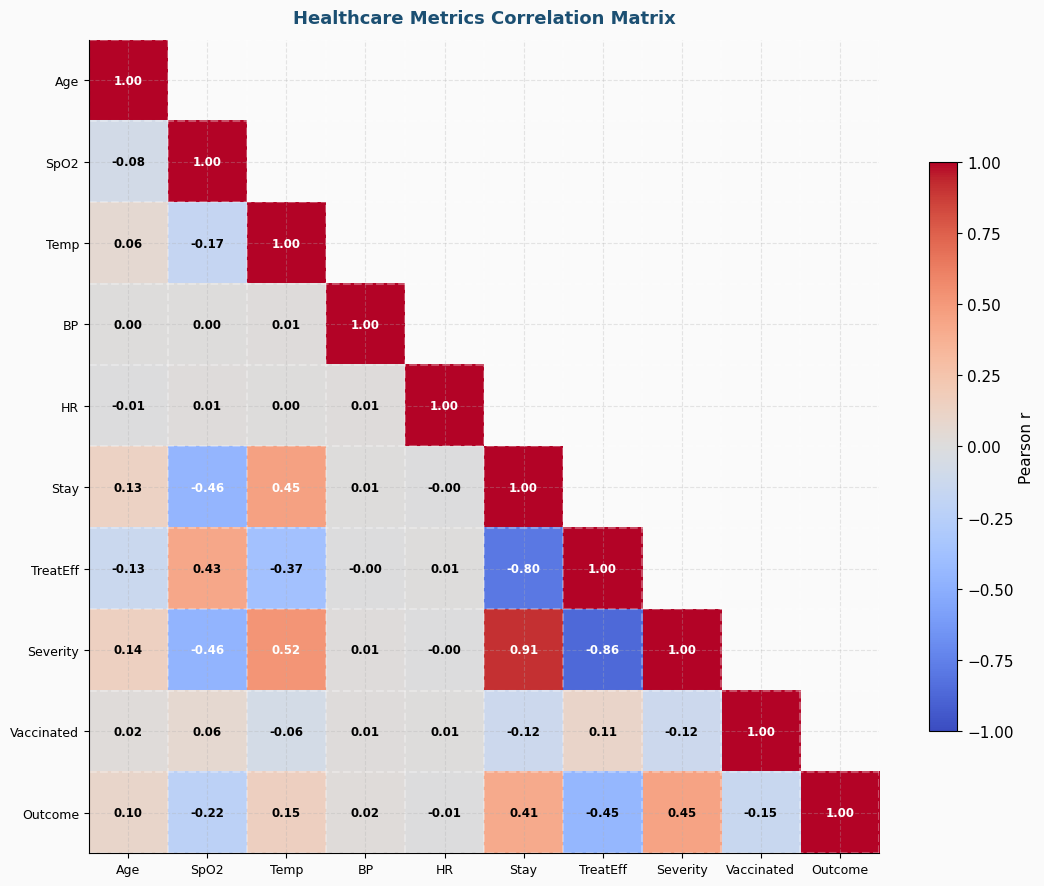

In [12]:
df['outcome_num']  = (df['outcome']=='Deceased').astype(int)
df['severity_num'] = df['severity'].map({'Mild':1,'Moderate':2,'Severe':3,'Critical':4})
df['vaccinated']   = (df['vaccine_status']!='Not Vaccinated').astype(int)

num_cols   = ['age','spo2_admission','temperature_f','systolic_bp','heart_rate',
              'hospital_stay_days','treatment_effectiveness_pct',
              'severity_num','vaccinated','outcome_num']
col_labels = ['Age','SpO2','Temp','BP','HR','Stay','TreatEff','Severity','Vaccinated','Outcome']
corr_vals  = df[num_cols].corr().values
n = len(col_labels)

fig, ax = plt.subplots(figsize=(11, 9))
fig.patch.set_facecolor('#FAFAFA')
mask = np.triu(np.ones((n,n), dtype=bool), k=1)
im = ax.imshow(np.where(mask, np.nan, corr_vals), cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
for i in range(n):
    for j in range(n):
        if not mask[i,j]:
            val = corr_vals[i,j]
            tc  = 'white' if abs(val)>0.45 else 'black'
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                    fontsize=8.5, fontweight='bold', color=tc)
ax.set_xticks(range(n)); ax.set_yticks(range(n))
ax.set_xticklabels(col_labels, fontsize=9)
ax.set_yticklabels(col_labels, fontsize=9)
ax.set_xticks(np.arange(-0.5,n,1), minor=True)
ax.set_yticks(np.arange(-0.5,n,1), minor=True)
ax.grid(which='minor', color='white', linewidth=1.5)
ax.tick_params(which='minor', bottom=False, left=False)
fig.colorbar(im, ax=ax, shrink=0.7, label='Pearson r')
ax.set_title('Healthcare Metrics Correlation Matrix',
             fontsize=13, fontweight='bold', color='#1B4F72', pad=12)
plt.tight_layout()
plt.show()

---
## CELL 13 — Summary & Recommendations

In [13]:
uv_mort = df[df['vaccine_status']=='Not Vaccinated']['outcome'].apply(lambda x:x=='Deceased').mean()*100
v_mort  = df[df['vaccine_status']!='Not Vaccinated']['outcome'].apply(lambda x:x=='Deceased').mean()*100
cr_mort = df[df['severity']=='Critical']['outcome'].apply(lambda x:x=='Deceased').mean()*100
old_mort= df[df['age']>60]['outcome'].apply(lambda x:x=='Deceased').mean()*100

print('=' * 58)
print('  PROJECT 4: HEALTHCARE - INSIGHTS & RECOMMENDATIONS')
print('=' * 58)
print(f'  Overall mortality rate     : {mort_rate:.2f}%')
print(f'  Unvaccinated mortality     : {uv_mort:.1f}%  vs  vaccinated: {v_mort:.1f}%')
print(f'  Critical severity mortality: {cr_mort:.1f}%')
print(f'  Age > 60 mortality         : {old_mort:.1f}%')
print('\n  RECOMMENDATIONS:')
print('  1. Prioritise ICU for patients over 60 with comorbidities')
print('  2. SpO2 < 92 on admission -> immediate escalation protocol')
print('  3. Vaccination drives must target unvaccinated in high-burden states')
print('  4. Heart Disease patients need dedicated cardiac monitoring')
print('  5. Scale oxygen therapy -- highest effectiveness score overall')
print('=' * 58)

  PROJECT 4: HEALTHCARE - INSIGHTS & RECOMMENDATIONS
  Overall mortality rate     : 8.74%
  Unvaccinated mortality     : 14.4%  vs  vaccinated: 5.7%
  Critical severity mortality: 57.9%
  Age > 60 mortality         : 14.6%

  RECOMMENDATIONS:
  1. Prioritise ICU for patients over 60 with comorbidities
  2. SpO2 < 92 on admission -> immediate escalation protocol
  3. Vaccination drives must target unvaccinated in high-burden states
  4. Heart Disease patients need dedicated cardiac monitoring
  5. Scale oxygen therapy -- highest effectiveness score overall
